# Capstone Project - Himalayan Landslide Intelligence System

### Task 5 - Video Presentation, video is divided into 2 parts
- Part 1 - https://www.loom.com/share/4efb74befa104ca4b33473854434b852
- Part 2 - https://www.loom.com/share/df61d98e72fa478e827e0de552ebceda

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df = pd.read_csv("landslides_data.csv")
df.head()

,objectid,source_name,source_link,event_id,event_date,event_time,event_title,event_description,location_description,location_accuracy,...,event_import_id,latitude,longitude,country_name,country_code,admin_division_name,gazetteer_closest_point,gazetteer_distance,submitted_date,last_edited_date
0,3,The Arunachal Times,http://www.arunachaltimes.in/six-killed-in-meg...,10987,1.497658e+12,NaN,Fatal landslide in Umiam,Landslide following continuous rain kills 3 in...,"Umiam, Ribhoi, Meghalaya",5km,...,NaN,25.678368,91.923434,India,IN,Meghalaya,Shillong,6.30,1.499712e+12,NaN
1,6,Kashmir Observer,http://www.kashmirobserver.net/index.php?optio...,1769,1.271722e+12,NaN,"India Gate(?), Srinagar-Leh highway, Kashmir",Sources said several landslides also occurred ...,"India Gate(?), Srinagar-Leh highway, Kashmir",unknown,...,1769,34.386675,76.341492,India,IN,Jammu and Kashmir,Goma,7.35,1.396310e+12,NaN
2,7,assamtribune,http://www.assamtribune.com/scripts/detailsnew...,1770,1.271722e+12,NaN,"Kharghuli, Guwahati, Assam","GUWAHATI, April 20 – Civic woes of Guwahatians...","Kharghuli, Guwahati, Assam",1km,...,1770,26.196500,91.763000,India,IN,Assam,Gauhati,1.77,1.396310e+12,NaN
3,11,The Indian Express,http://indianexpress.com/article/india/india-o...,7972,1.440726e+12,02:00,"Mizoram, India",A downpour was drenching the old building at 1...,"Mizoram, India",25km,...,7972,23.449500,92.811200,India,IN,Mizoram,Mizoram,9.74,1.467304e+12,NaN
4,14,alertnet,http://www.alertnet.org/thenews/fromthefield/2...,2206,1.281055e+12,00:00,"villages Shapoo(?), Bazgo(?) and wide area aro...","On the night of 5th and 6th August 2010, betwe...","villages Shapoo(?), Bazgo(?) and wide area aro...",50km,...,2206,34.141600,77.487100,India,IN,Jammu and Kashmir,Leh,5.74,1.410457e+12,NaN


## Task 2 - Data cleaning and preprocessing

In [38]:
df.columns

Index(['objectid', 'source_name', 'source_link', 'event_id', 'event_date',
       'event_time', 'event_title', 'event_description',
       'location_description', 'location_accuracy', 'landslide_category',
       'landslide_trigger', 'landslide_size', 'landslide_setting',
       'fatality_count', 'injury_count', 'storm_name', 'photo_link',
       'comments', 'event_import_source', 'event_import_id', 'latitude',
       'longitude', 'country_name', 'country_code', 'admin_division_name',
       'gazetteer_closest_point', 'gazetteer_distance', 'submitted_date',
       'last_edited_date'],
      dtype='object')

In [39]:
df['event_import_source'].unique()

array(['GLC', 'LRC', 'SMMML'], dtype=object)

In [40]:
df = df.drop(columns = [
    'objectid', 'event_id', 'event_import_id', 'source_link', 'photo_link', 'comments', 'country_code', 'submitted_date', 'last_edited_date'
])

In [41]:
df.shape

(2000, 21)

In [42]:
df.isnull().sum()

source_name                   0
event_date                    2
event_time                 1246
event_title                   0
event_description            12
location_description         16
location_accuracy             1
landslide_category            0
landslide_trigger             0
landslide_size                0
landslide_setting             0
fatality_count              381
injury_count               1137
storm_name                 1981
event_import_source           0
latitude                      0
longitude                     0
country_name                  0
admin_division_name           0
gazetteer_closest_point       0
gazetteer_distance            0
dtype: int64

In [43]:
himalayan_regions = [

    # India
    'Jammu and Kashmir',
    'Himachal Pradesh',
    'Uttaranchal',   # old name for Uttarakhand
    'Sikkim',
    'Arunachal Pradesh',

    # Northeast 
    'Meghalaya',
    'Assam',
    'Mizoram',
    'Nagaland',
    'Manipur',
    'Tripura',

    # Nepal regions
    'Gandaki',
    'Seti',
    'Bheri',
    'Narayani',
    'Dhawalagiri',
    'Rapti',
    'Bagmati',
    'Sagarmatha',
    'Janakpur',
    'Lumbini',
    'Koshi',
    'Karnali',
    'Mechi',
    'Mahakali'
]

In [44]:
# extract data only for himalayan regions
himalaya_df = df[
    df['admin_division_name'].isin(himalayan_regions)
].copy()
himalaya_df.shape

(1567, 21)

In [45]:
himalaya_df.isnull().sum()

source_name                   0
event_date                    2
event_time                 1028
event_title                   0
event_description             7
location_description         15
location_accuracy             1
landslide_category            0
landslide_trigger             0
landslide_size                0
landslide_setting             0
fatality_count              280
injury_count                875
storm_name                 1561
event_import_source           0
latitude                      0
longitude                     0
country_name                  0
admin_division_name           0
gazetteer_closest_point       0
gazetteer_distance            0
dtype: int64

In [46]:
# dropping columns as they are mostly empty and filling them w mean, mode values would give us fake data
himalaya_df = himalaya_df.drop(columns=['event_time','injury_count','storm_name'])

In [47]:
himalaya_df.shape

(1567, 18)

In [48]:
himalaya_df.head()

,source_name,event_date,event_title,event_description,location_description,location_accuracy,landslide_category,landslide_trigger,landslide_size,landslide_setting,fatality_count,event_import_source,latitude,longitude,country_name,admin_division_name,gazetteer_closest_point,gazetteer_distance
0,The Arunachal Times,1.497658e+12,Fatal landslide in Umiam,Landslide following continuous rain kills 3 in...,"Umiam, Ribhoi, Meghalaya",5km,landslide,continuous_rain,medium,unknown,3.0,GLC,25.678368,91.923434,India,Meghalaya,Shillong,6.30
1,Kashmir Observer,1.271722e+12,"India Gate(?), Srinagar-Leh highway, Kashmir",Sources said several landslides also occurred ...,"India Gate(?), Srinagar-Leh highway, Kashmir",unknown,landslide,downpour,medium,above_road,0.0,GLC,34.386675,76.341492,India,Jammu and Kashmir,Goma,7.35
2,assamtribune,1.271722e+12,"Kharghuli, Guwahati, Assam","GUWAHATI, April 20 – Civic woes of Guwahatians...","Kharghuli, Guwahati, Assam",1km,landslide,downpour,medium,unknown,0.0,GLC,26.196500,91.763000,India,Assam,Gauhati,1.77
3,The Indian Express,1.440726e+12,"Mizoram, India",A downpour was drenching the old building at 1...,"Mizoram, India",25km,landslide,downpour,large,unknown,0.0,GLC,23.449500,92.811200,India,Mizoram,Mizoram,9.74
4,alertnet,1.281055e+12,"villages Shapoo(?), Bazgo(?) and wide area aro...","On the night of 5th and 6th August 2010, betwe...","villages Shapoo(?), Bazgo(?) and wide area aro...",50km,landslide,downpour,very_large,unknown,234.0,GLC,34.141600,77.487100,India,Jammu and Kashmir,Leh,5.74


In [49]:
himalaya_df.dtypes

source_name                 object
event_date                 float64
event_title                 object
event_description           object
location_description        object
location_accuracy           object
landslide_category          object
landslide_trigger           object
landslide_size              object
landslide_setting           object
fatality_count             float64
event_import_source         object
latitude                   float64
longitude                  float64
country_name                object
admin_division_name         object
gazetteer_closest_point     object
gazetteer_distance         float64
dtype: object

In [50]:
himalaya_df['landslide_setting'].unique()

array(['unknown', 'above_road', 'urban', 'retaining_wall',
       'deforested_slope', 'engineered_slope', 'natural_slope',
       'burned_area', 'mine', 'below_road', 'other', 'above_river'],
      dtype=object)

In [51]:
# converting event_date to datetime format
himalaya_df['event_date'] = pd.to_datetime(himalaya_df['event_date'], unit='ms').dt.date
himalaya_df['event_date']

0       2017-06-17
1       2010-04-20
2       2010-04-20
3       2015-08-28
4       2010-08-06
           ...    
1994    2013-07-15
1995    2017-08-13
1996    2016-08-05
1997    2011-03-19
1998    2017-04-04
Name: event_date, Length: 1567, dtype: object

In [52]:
# location_accuracy from object to int
himalaya_df.rename(columns={'location_accuracy':'location_accuracy_km'}, inplace=True)

In [53]:
himalaya_df['location_accuracy_km'] = himalaya_df['location_accuracy_km'].str.replace("km","")
himalaya_df['location_accuracy_km'].unique()

array(['5', 'unknown', '1', '25', '50', '10', '100', 'exact', nan, '250'],
      dtype=object)

In [54]:
(himalaya_df["location_accuracy_km"] == "unknown").sum()

np.int64(67)

In [55]:
# Replace text values
himalaya_df["location_accuracy_km"] = himalaya_df["location_accuracy_km"].replace({
    "exact": 0,
    "unknown": None
})

# Convert entire column to numeric
himalaya_df["location_accuracy_km"] = pd.to_numeric(
    himalaya_df["location_accuracy_km"],
    errors="coerce"
)

# Fill missing values with median
median_val = himalaya_df["location_accuracy_km"].median()

himalaya_df["location_accuracy_km"].fillna(median_val, inplace=True)
himalaya_df["location_accuracy_km"].unique()

C:\Users\Nandini\AppData\Local\Temp\ipykernel_19604\3839522868.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  himalaya_df["location_accuracy_km"].fillna(median_val, inplace=True)


array([  5.,   1.,  25.,  50.,  10., 100.,   0., 250.])

In [56]:
himalaya_df.dtypes

source_name                 object
event_date                  object
event_title                 object
event_description           object
location_description        object
location_accuracy_km       float64
landslide_category          object
landslide_trigger           object
landslide_size              object
landslide_setting           object
fatality_count             float64
event_import_source         object
latitude                   float64
longitude                  float64
country_name                object
admin_division_name         object
gazetteer_closest_point     object
gazetteer_distance         float64
dtype: object

In [57]:
himalaya_df['landslide_trigger'].unique()

array(['continuous_rain', 'downpour', 'monsoon', 'rain',
       'snowfall_snowmelt', 'construction', 'unknown', 'earthquake',
       'tropical_cyclone', 'no_apparent_trigger', 'flooding', 'mining',
       'other'], dtype=object)

In [58]:
himalaya_df["landslide_trigger"] = himalaya_df["landslide_trigger"].replace({
    "continuous_rain": "rainfall",
    "downpour": "rainfall",
    "monsoon": "rainfall",
    "rain": "rainfall"
})
himalaya_df['landslide_trigger'].unique()

array(['rainfall', 'snowfall_snowmelt', 'construction', 'unknown',
       'earthquake', 'tropical_cyclone', 'no_apparent_trigger',
       'flooding', 'mining', 'other'], dtype=object)

In [59]:
himalaya_df['landslide_size'].unique()

array(['medium', 'large', 'very_large', 'small', 'unknown'], dtype=object)

In [60]:
# Replace categories with numeric values
himalaya_df["landslide_size"] = himalaya_df["landslide_size"].replace({
    "small": 1,
    "medium": 2,
    "large": 3,
    "very_large": 4,
    "unknown": None
})

# Convert to numeric
himalaya_df["landslide_size"] = pd.to_numeric(
    himalaya_df["landslide_size"],
    errors="coerce"
)

# Fill missing values with median
median_size = himalaya_df["landslide_size"].median()

himalaya_df["landslide_size"] = himalaya_df["landslide_size"].fillna(median_size)
himalaya_df['landslide_size'].unique()

C:\Users\Nandini\AppData\Local\Temp\ipykernel_19604\480232661.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  himalaya_df["landslide_size"] = himalaya_df["landslide_size"].replace({


array([2., 3., 4., 1.])

In [61]:
himalaya_df["landslide_setting"].unique()

array(['unknown', 'above_road', 'urban', 'retaining_wall',
       'deforested_slope', 'engineered_slope', 'natural_slope',
       'burned_area', 'mine', 'below_road', 'other', 'above_river'],
      dtype=object)

In [62]:
himalaya_df["landslide_setting"] = himalaya_df["landslide_setting"].replace({
    "above_road": "infrastructure",
    "below_road": "infrastructure",
    "retaining_wall": "infrastructure",

    "natural_slope": "natural",
    "above_river": "natural",

    "urban": "human_modified",
    "engineered_slope": "human_modified",
    "deforested_slope": "human_modified",
    "mine": "human_modified",

    "burned_area": "disturbed_nature",

    "unknown": "unknown",
    "other": "other"
})
himalaya_df["landslide_setting"].unique()

array(['unknown', 'infrastructure', 'human_modified', 'natural',
       'disturbed_nature', 'other'], dtype=object)

In [63]:
himalaya_df["fatality_count"].unique()

array([3.00e+00, 0.00e+00, 2.34e+02, 1.00e+00, 8.00e+00,      nan,
       6.00e+00, 2.00e+00, 1.40e+01, 4.00e+00, 1.00e+01, 5.00e+00,
       1.70e+01, 9.00e+00, 7.00e+00, 1.20e+01, 2.10e+01, 5.00e+03,
       1.60e+01, 5.30e+01, 1.10e+01, 3.80e+01, 2.00e+01, 6.00e+01,
       1.30e+01, 2.40e+01, 2.80e+01, 1.90e+01, 1.82e+02, 4.00e+01,
       1.50e+01, 1.80e+01, 2.50e+02, 2.50e+01, 7.20e+01, 4.10e+01,
       2.60e+01, 1.74e+02])

In [64]:
# Ensure numeric (just in case)
himalaya_df["fatality_count"] = pd.to_numeric(
    himalaya_df["fatality_count"],
    errors="coerce"
)

# Compute median (ignores NaN automatically)
median_val = himalaya_df["fatality_count"].median()

# Fill NaN with median
himalaya_df["fatality_count"] = himalaya_df["fatality_count"].fillna(median_val)
himalaya_df["fatality_count"].unique()

array([3.00e+00, 0.00e+00, 2.34e+02, 1.00e+00, 8.00e+00, 6.00e+00,
       2.00e+00, 1.40e+01, 4.00e+00, 1.00e+01, 5.00e+00, 1.70e+01,
       9.00e+00, 7.00e+00, 1.20e+01, 2.10e+01, 5.00e+03, 1.60e+01,
       5.30e+01, 1.10e+01, 3.80e+01, 2.00e+01, 6.00e+01, 1.30e+01,
       2.40e+01, 2.80e+01, 1.90e+01, 1.82e+02, 4.00e+01, 1.50e+01,
       1.80e+01, 2.50e+02, 2.50e+01, 7.20e+01, 4.10e+01, 2.60e+01,
       1.74e+02])

In [65]:
# where we got the data from
himalaya_df['event_import_source'].unique()

array(['GLC', 'SMMML', 'LRC'], dtype=object)

In [66]:
himalaya_df['latitude'].unique()

array([25.67836832, 34.38667467, 26.1965    , ..., 29.5866    ,
       33.2466    , 25.118398  ], shape=(1535,))

In [67]:
himalaya_df['longitude'].unique()

array([91.9234343 , 76.34149164, 91.763     , ..., 80.2154    ,
       75.1611    , 92.853913  ], shape=(1541,))

In [68]:
himalaya_df['country_name'].unique()

array(['India', 'Nepal'], dtype=object)

In [69]:
himalaya_df['gazetteer_distance'].unique()

array([ 6.3 ,  7.35,  1.77, ..., 20.62, 14.61,  3.23], shape=(1181,))

In [70]:
himalaya_df.isnull().sum()

source_name                 0
event_date                  2
event_title                 0
event_description           7
location_description       15
location_accuracy_km        0
landslide_category          0
landslide_trigger           0
landslide_size              0
landslide_setting           0
fatality_count              0
event_import_source         0
latitude                    0
longitude                   0
country_name                0
admin_division_name         0
gazetteer_closest_point     0
gazetteer_distance          0
dtype: int64

In [71]:
himalaya_df.dropna(subset=["event_date"], inplace=True)

In [72]:
himalaya_df['event_description'] = himalaya_df['event_description'].fillna('None')

In [73]:
himalaya_df['location_description'] = himalaya_df['location_description'].fillna('None')

In [74]:
himalaya_df.duplicated().sum()

np.int64(4)

In [75]:
himalaya_df[himalaya_df.duplicated()]

,source_name,event_date,event_title,event_description,location_description,location_accuracy_km,landslide_category,landslide_trigger,landslide_size,landslide_setting,fatality_count,event_import_source,latitude,longitude,country_name,admin_division_name,gazetteer_closest_point,gazetteer_distance
940,Dailyhunt,2017-04-16,Multiple rockfalls along Batote-Doda Road,Rockfalls along road force its complete closur...,"Batote-Doda Road, Doda, Jammu & Kashmir, India",10.0,rock_fall,rainfall,1.0,infrastructure,0.0,GLC,33.129217,75.446189,India,Jammu and Kashmir,Doda,9.65
1679,State Times,2017-04-08,Landslide on Batote-Doda-Kishtwar National Hig...,Landslide above road near Assar totally blocks...,"near Assar, Doda, Jammu & Kashmir",10.0,landslide,unknown,2.0,infrastructure,0.0,GLC,33.121729,75.408562,India,Jammu and Kashmir,Doda,13.26
1883,Himalayan Times,2017-06-04,Landslide in Tapeljung,Rain causes landslide to block Mechi highway,Mechi highway near the Khokse River at Dokhu a...,0.0,landslide,rainfall,2.0,infrastructure,0.0,GLC,27.338613,87.671072,Nepal,Mechi,Libang,11.07
1945,Quakemap,2015-05-03,trail between Phillim and Lokpa,25 army personnel has been helicoptered in and...,trail between Phillim and Lokpa,5.0,landslide,unknown,1.0,unknown,0.0,GLC,28.420200,84.899600,Nepal,Gandaki,Ku-la-ko,19.67


In [76]:
himalaya_df.drop_duplicates(inplace=True)

Feature Engineering

In [77]:
himalaya_df.dtypes

source_name                 object
event_date                  object
event_title                 object
event_description           object
location_description        object
location_accuracy_km       float64
landslide_category          object
landslide_trigger           object
landslide_size             float64
landslide_setting           object
fatality_count             float64
event_import_source         object
latitude                   float64
longitude                  float64
country_name                object
admin_division_name         object
gazetteer_closest_point     object
gazetteer_distance         float64
dtype: object

In [78]:
# date
himalaya_df["event_date"] = pd.to_datetime(himalaya_df["event_date"], errors="coerce")

In [79]:
# extracting month, year and defining season
himalaya_df["year"] = himalaya_df["event_date"].dt.year
himalaya_df["month"] = himalaya_df["event_date"].dt.month

himalaya_df["season"] = himalaya_df["month"].apply(
    lambda x: "monsoon" if x in [6,7,8,9] else "non_monsoon"
)

In [80]:
geo_features = ['latitude','longitude','gazetteer_distance']

In [81]:
himalaya_df["country_name"] = himalaya_df["country_name"].map({
    "India": 0,
    "Nepal": 1
})

In [82]:
himalaya_df["severity"] = pd.cut(
    himalaya_df["fatality_count"],
    bins=[-1, 0, 10, float("inf")],
    labels=["low", "medium", "high"]
)

In [83]:
himalaya_df.shape

(1561, 22)

In [84]:
himalaya_df.head()

,source_name,event_date,event_title,event_description,location_description,location_accuracy_km,landslide_category,landslide_trigger,landslide_size,landslide_setting,...,latitude,longitude,country_name,admin_division_name,gazetteer_closest_point,gazetteer_distance,year,month,season,severity
0,The Arunachal Times,2017-06-17,Fatal landslide in Umiam,Landslide following continuous rain kills 3 in...,"Umiam, Ribhoi, Meghalaya",5.0,landslide,rainfall,2.0,unknown,...,25.678368,91.923434,0,Meghalaya,Shillong,6.30,2017,6,monsoon,medium
1,Kashmir Observer,2010-04-20,"India Gate(?), Srinagar-Leh highway, Kashmir",Sources said several landslides also occurred ...,"India Gate(?), Srinagar-Leh highway, Kashmir",5.0,landslide,rainfall,2.0,infrastructure,...,34.386675,76.341492,0,Jammu and Kashmir,Goma,7.35,2010,4,non_monsoon,low
2,assamtribune,2010-04-20,"Kharghuli, Guwahati, Assam","GUWAHATI, April 20 – Civic woes of Guwahatians...","Kharghuli, Guwahati, Assam",1.0,landslide,rainfall,2.0,unknown,...,26.196500,91.763000,0,Assam,Gauhati,1.77,2010,4,non_monsoon,low
3,The Indian Express,2015-08-28,"Mizoram, India",A downpour was drenching the old building at 1...,"Mizoram, India",25.0,landslide,rainfall,3.0,unknown,...,23.449500,92.811200,0,Mizoram,Mizoram,9.74,2015,8,monsoon,low
4,alertnet,2010-08-06,"villages Shapoo(?), Bazgo(?) and wide area aro...","On the night of 5th and 6th August 2010, betwe...","villages Shapoo(?), Bazgo(?) and wide area aro...",50.0,landslide,rainfall,4.0,unknown,...,34.141600,77.487100,0,Jammu and Kashmir,Leh,5.74,2010,8,monsoon,high


In [85]:
himalaya_df.to_csv('himalayan_landslides.csv', index=False)

# Task 3 - Exploratory Data Analysis and Visualization

In [86]:
# himalaya_df.columns

In [87]:
himalaya_df.shape

(1561, 22)

In [88]:
himalaya_df.dtypes

source_name                        object
event_date                 datetime64[ns]
event_title                        object
event_description                  object
location_description               object
location_accuracy_km              float64
landslide_category                 object
landslide_trigger                  object
landslide_size                    float64
landslide_setting                  object
fatality_count                    float64
event_import_source                object
latitude                          float64
longitude                         float64
country_name                        int64
admin_division_name                object
gazetteer_closest_point            object
gazetteer_distance                float64
year                                int32
month                               int32
season                             object
severity                         category
dtype: object

In [89]:
himalaya_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1561 entries, 0 to 1998
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   source_name              1561 non-null   object        
 1   event_date               1561 non-null   datetime64[ns]
 2   event_title              1561 non-null   object        
 3   event_description        1561 non-null   object        
 4   location_description     1561 non-null   object        
 5   location_accuracy_km     1561 non-null   float64       
 6   landslide_category       1561 non-null   object        
 7   landslide_trigger        1561 non-null   object        
 8   landslide_size           1561 non-null   float64       
 9   landslide_setting        1561 non-null   object        
 10  fatality_count           1561 non-null   float64       
 11  event_import_source      1561 non-null   object        
 12  latitude                 1561 non-null 

In [90]:
himalaya_df.describe()

,event_date,location_accuracy_km,landslide_size,fatality_count,latitude,longitude,country_name,gazetteer_distance,year,month
count,1561,1561.000000,1561.000000,1561.000000,1561.000000,1561.000000,1561.000000,1561.000000,1561.000000,1561.000000
mean,2013-10-24 04:42:16.835362048,14.924407,1.953235,5.089686,29.015394,83.724196,0.319667,12.368751,2013.267777,7.096092
min,1990-01-28 00:00:00,0.000000,1.000000,0.000000,22.479000,73.961000,0.000000,0.010000,1990.000000,1.000000
25%,2011-02-13 00:00:00,5.000000,2.000000,0.000000,27.186100,77.591400,0.000000,6.110000,2011.000000,6.000000
50%,2013-09-03 00:00:00,5.000000,2.000000,0.000000,28.292900,83.374200,0.000000,11.250000,2013.000000,7.000000
75%,2016-07-25 00:00:00,25.000000,2.000000,1.000000,31.102692,88.733400,1.000000,17.560000,2016.000000,8.000000
max,2021-06-12 00:00:00,250.000000,4.000000,5000.000000,34.665100,96.926200,1.000000,51.230000,2021.000000,12.000000
std,NaN,18.506809,0.481442,127.026772,2.796835,6.680448,0.466497,8.651783,3.166539,2.003136


In [91]:
himalaya_df.describe(include='all')

,source_name,event_date,event_title,event_description,location_description,location_accuracy_km,landslide_category,landslide_trigger,landslide_size,landslide_setting,...,latitude,longitude,country_name,admin_division_name,gazetteer_closest_point,gazetteer_distance,year,month,season,severity
count,1561,1561,1561,1561,1561,1561.000000,1561,1561,1561.000000,1561,...,1561.000000,1561.000000,1561.000000,1561,1561,1561.000000,1561.000000,1561.000000,1561,1561
unique,397,NaN,1521,1410,1502,NaN,10,10,NaN,6,...,NaN,NaN,NaN,25,348,NaN,NaN,NaN,2,3
top,thehimalayantimes,NaN,Landslide blocks road,BAJURA: Continuous rainfall for the past few d...,None,NaN,landslide,rainfall,NaN,unknown,...,NaN,NaN,NaN,Jammu and Kashmir,Gund,NaN,NaN,NaN,monsoon,low
freq,68,NaN,3,7,13,NaN,1381,1327,NaN,980,...,NaN,NaN,NaN,244,34,NaN,NaN,NaN,1216,1089
mean,NaN,2013-10-24 04:42:16.835362048,NaN,NaN,NaN,14.924407,NaN,NaN,1.953235,NaN,...,29.015394,83.724196,0.319667,NaN,NaN,12.368751,2013.267777,7.096092,NaN,NaN
min,NaN,1990-01-28 00:00:00,NaN,NaN,NaN,0.000000,NaN,NaN,1.000000,NaN,...,22.479000,73.961000,0.000000,NaN,NaN,0.010000,1990.000000,1.000000,NaN,NaN
25%,NaN,2011-02-13 00:00:00,NaN,NaN,NaN,5.000000,NaN,NaN,2.000000,NaN,...,27.186100,77.591400,0.000000,NaN,NaN,6.110000,2011.000000,6.000000,NaN,NaN
50%,NaN,2013-09-03 00:00:00,NaN,NaN,NaN,5.000000,NaN,NaN,2.000000,NaN,...,28.292900,83.374200,0.000000,NaN,NaN,11.250000,2013.000000,7.000000,NaN,NaN
75%,NaN,2016-07-25 00:00:00,NaN,NaN,NaN,25.000000,NaN,NaN,2.000000,NaN,...,31.102692,88.733400,1.000000,NaN,NaN,17.560000,2016.000000,8.000000,NaN,NaN
max,NaN,2021-06-12 00:00:00,NaN,NaN,NaN,250.000000,NaN,NaN,4.000000,NaN,...,34.665100,96.926200,1.000000,NaN,NaN,51.230000,2021.000000,12.000000,NaN,NaN


In [92]:
himalaya_df.isnull().sum()

source_name                0
event_date                 0
event_title                0
event_description          0
location_description       0
location_accuracy_km       0
landslide_category         0
landslide_trigger          0
landslide_size             0
landslide_setting          0
fatality_count             0
event_import_source        0
latitude                   0
longitude                  0
country_name               0
admin_division_name        0
gazetteer_closest_point    0
gazetteer_distance         0
year                       0
month                      0
season                     0
severity                   0
dtype: int64

In [93]:
himalaya_df.duplicated().sum()

np.int64(0)

## Univariate Analysis

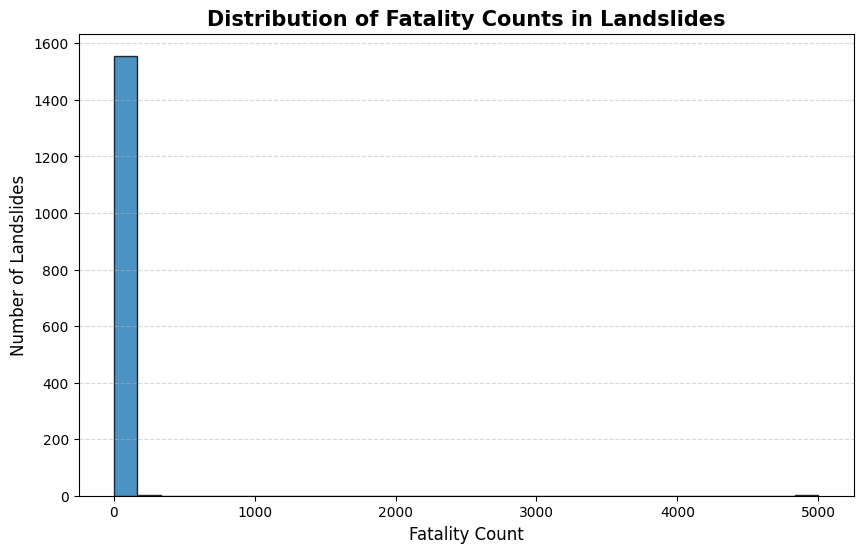

In [94]:
plt.figure(figsize=(10,6))

plt.hist(
    himalaya_df['fatality_count'],
    bins=30,
    edgecolor='black',
    alpha=0.8
)

plt.xlabel('Fatality Count', fontsize=12)
plt.ylabel('Number of Landslides', fontsize=12)

plt.title(
    'Distribution of Fatality Counts in Landslides',
    fontsize=15,
    fontweight='bold'
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Outlier Detection

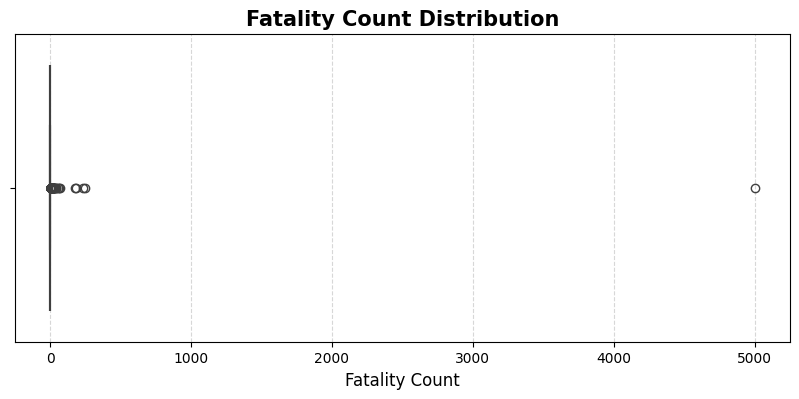

In [95]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=himalaya_df["fatality_count"],
    linewidth=1.5
)

plt.xlabel('Fatality Count', fontsize=12)

plt.title(
    'Fatality Count Distribution',
    fontsize=15,
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

Graph Analysis : 
- As we can see from the above 2 plots, fatality count is skewed towards 0, which means a lot of landslides were not extremely severe.
- This value gives us important data about the analysis and is realistic
- Thus even though the data is skewed, normalizing it would lead to false data and predictions, so we keep the data as it is.

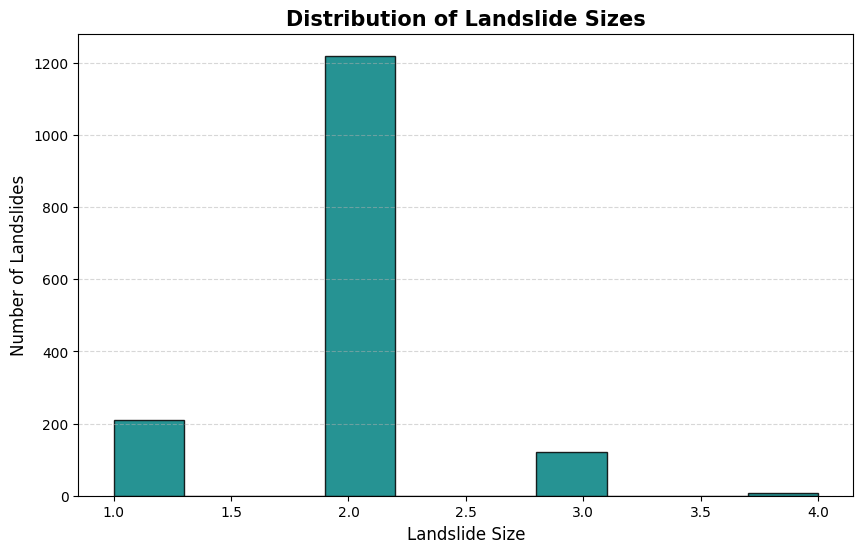

In [96]:
plt.figure(figsize=(10,6))

plt.hist(
    himalaya_df['landslide_size'],
    bins=10,
    color='teal',
    edgecolor='black',
    alpha=0.85
)

plt.xlabel('Landslide Size', fontsize=12)
plt.ylabel('Number of Landslides', fontsize=12)

plt.title(
    'Distribution of Landslide Sizes',
    fontsize=15,
    fontweight='bold'
)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

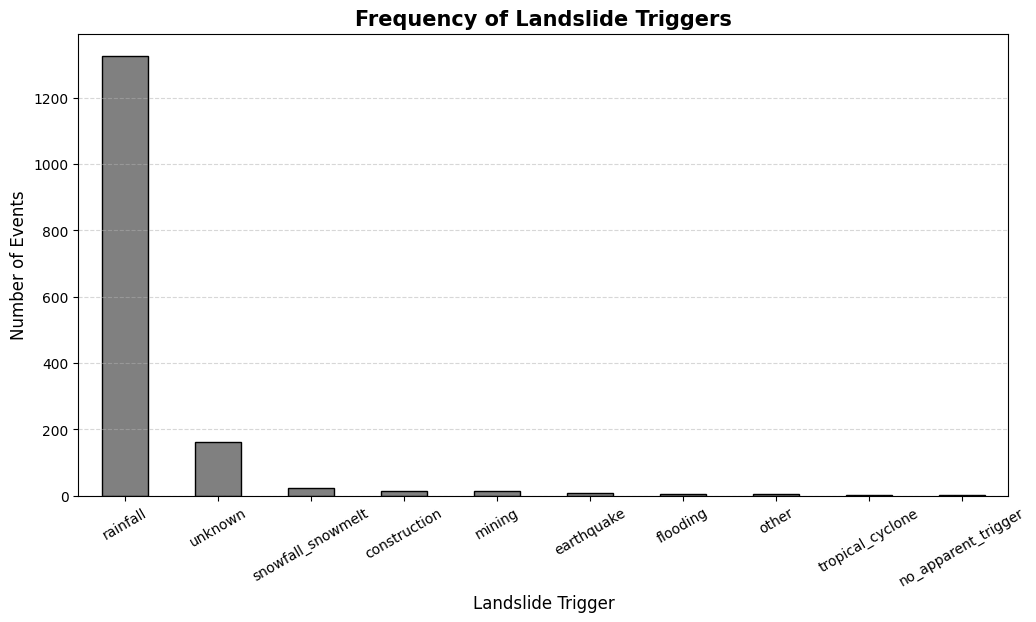

In [97]:
plt.figure(figsize=(12,6))

himalaya_df['landslide_trigger'].value_counts().plot(
    kind='bar',
    color='grey',
    edgecolor='black'
)

plt.xlabel('Landslide Trigger', fontsize=12)
plt.ylabel('Number of Events', fontsize=12)

plt.title(
    'Frequency of Landslide Triggers',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

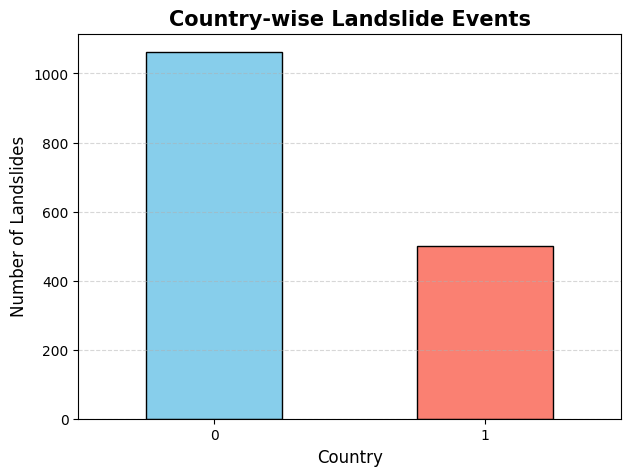

In [98]:
plt.figure(figsize=(7,5))

himalaya_df['country_name'].value_counts().plot(
    kind='bar',
    color=['skyblue', 'salmon'],
    edgecolor='black'
)

plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Landslides', fontsize=12)

plt.title(
    'Country-wise Landslide Events',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Graph Analysis :
0 - India, 1 - Nepal

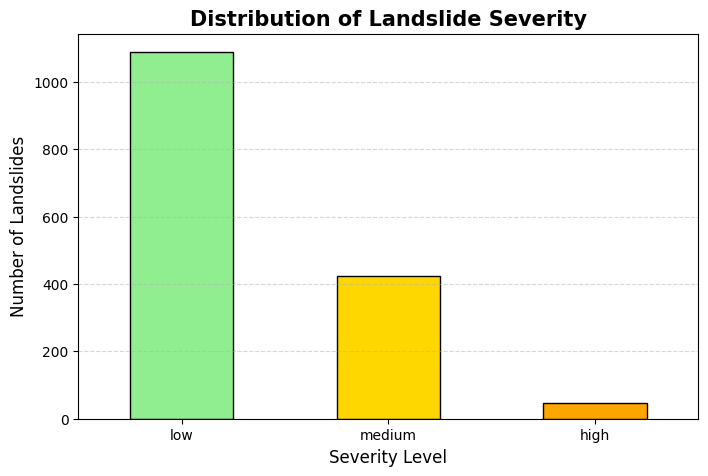

In [99]:
plt.figure(figsize=(8,5))

himalaya_df['severity'].value_counts().plot(
    kind='bar',
    color=['lightgreen', 'gold', 'orange', 'crimson'],
    edgecolor='black'
)

plt.xlabel('Severity Level', fontsize=12)
plt.ylabel('Number of Landslides', fontsize=12)

plt.title(
    'Distribution of Landslide Severity',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

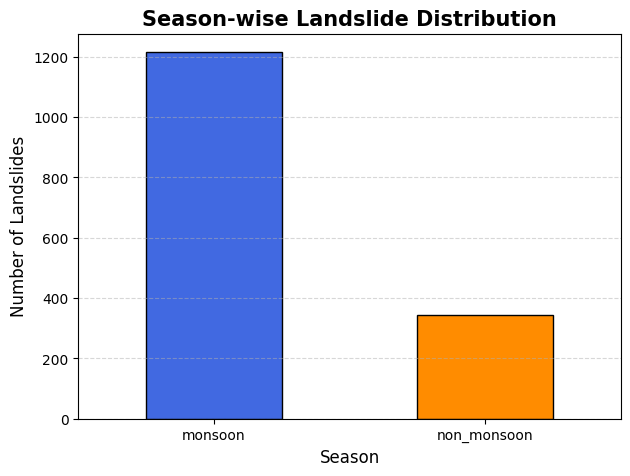

In [100]:
plt.figure(figsize=(7,5))

himalaya_df['season'].value_counts().plot(
    kind='bar',
    color=['royalblue', 'darkorange'],
    edgecolor='black'
)

plt.xlabel('Season', fontsize=12)
plt.ylabel('Number of Landslides', fontsize=12)

plt.title(
    'Season-wise Landslide Distribution',
    fontsize=15,
    fontweight='bold'
)

plt.xticks(rotation=0)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Bivariate Analysis

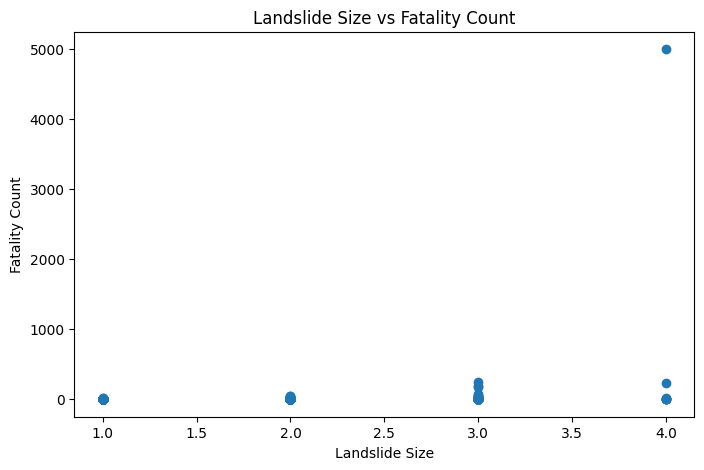

In [101]:
plt.figure(figsize=(8,5))
plt.scatter(himalaya_df['landslide_size'], himalaya_df['fatality_count'])
plt.xlabel('Landslide Size')
plt.ylabel('Fatality Count')
plt.title('Landslide Size vs Fatality Count')
plt.show()

Graph Analysis :
- Most landslides, regardless of size, caused low or zero fatalities because most points are clustered near the bottom.
- There are a few extreme outliers, especially one very large fatality event near 5000 deaths.

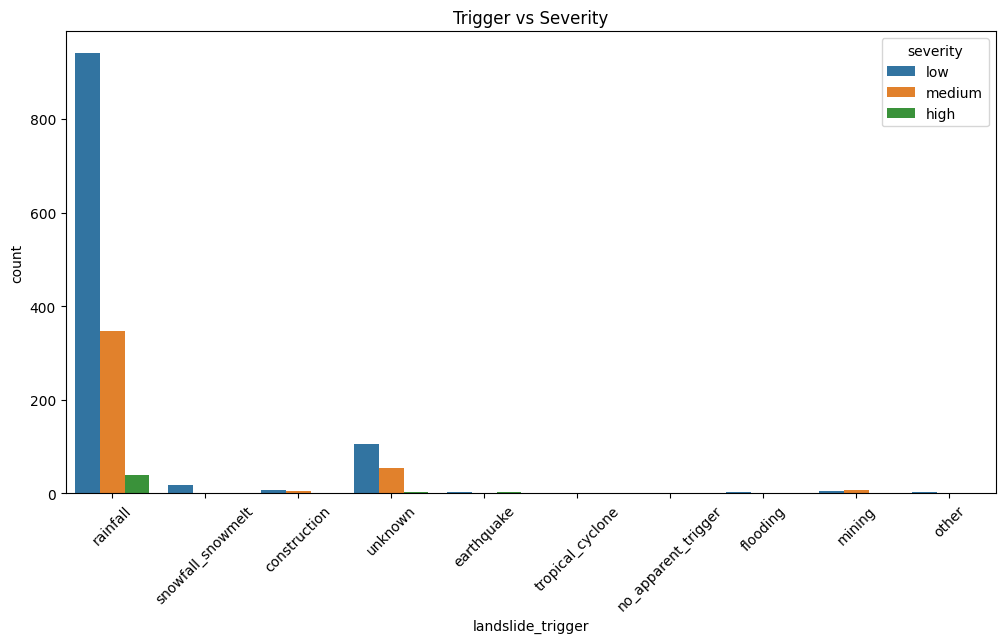

In [102]:
plt.figure(figsize=(12,6))
sns.countplot(data=himalaya_df, x='landslide_trigger', hue='severity')
plt.xticks(rotation=45)
plt.title('Trigger vs Severity')
plt.show()

Graph Analysis :
- the data is skewed towards rainfall and low severity count.
- It means that most of the landslides were triggered by rainfalls and had a low to medium fatality count due to rainfall as well as unknown triggers

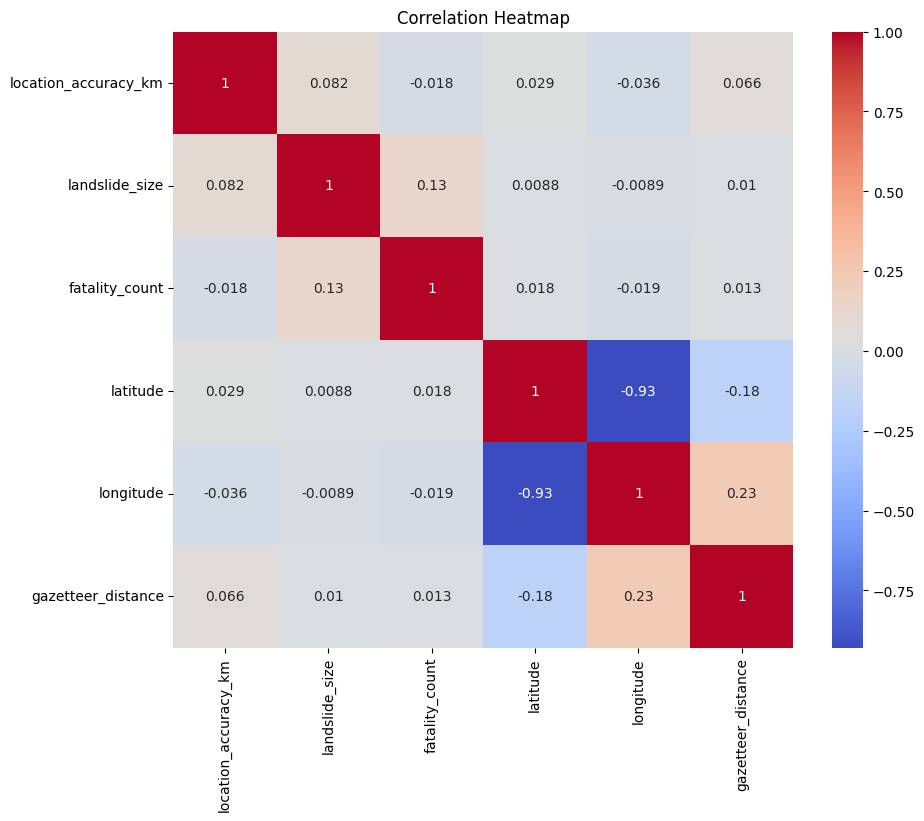

In [103]:
numeric_cols = himalaya_df.select_dtypes(include=np.number)
numeric_cols = numeric_cols.drop(columns=["year", "month", "country_name"])

corr = numeric_cols.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Graph Analysis : 
- There is a strong negative correlation between latitude and longitude, meaning it follows a slanted path, when latitude increases, longitude decreases.
- landslide size and fatality count have a slight positive correlation, meaning size affects fatality but not much, as previously seen in the size vs fatality graph

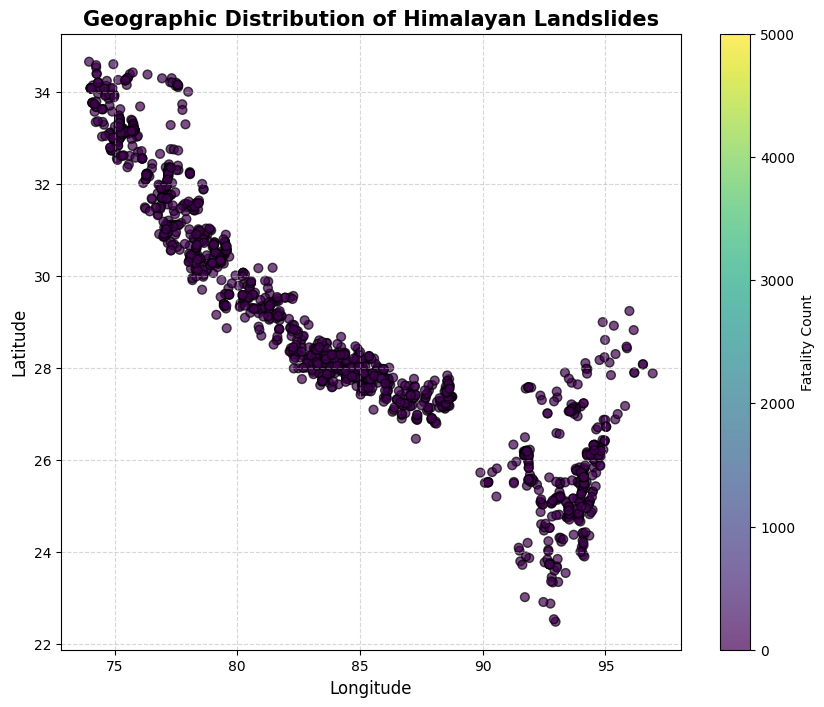

In [104]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    himalaya_df['longitude'],
    himalaya_df['latitude'],
    c=himalaya_df['fatality_count'],   # color based on fatalities
    s=40,                              # point size
    alpha=0.7,
    edgecolors='black'
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Fatality Count')

# Labels and title
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

plt.title(
    'Geographic Distribution of Himalayan Landslides',
    fontsize=15,
    fontweight='bold'
)

# Grid for readability
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Graph Analysis : 
- The landslides are concentrated more in North Indian Himalayan region and Nepal, and have lower concentration in North-east Himalayas
- Most landslides have a fatality count of 0-2000 

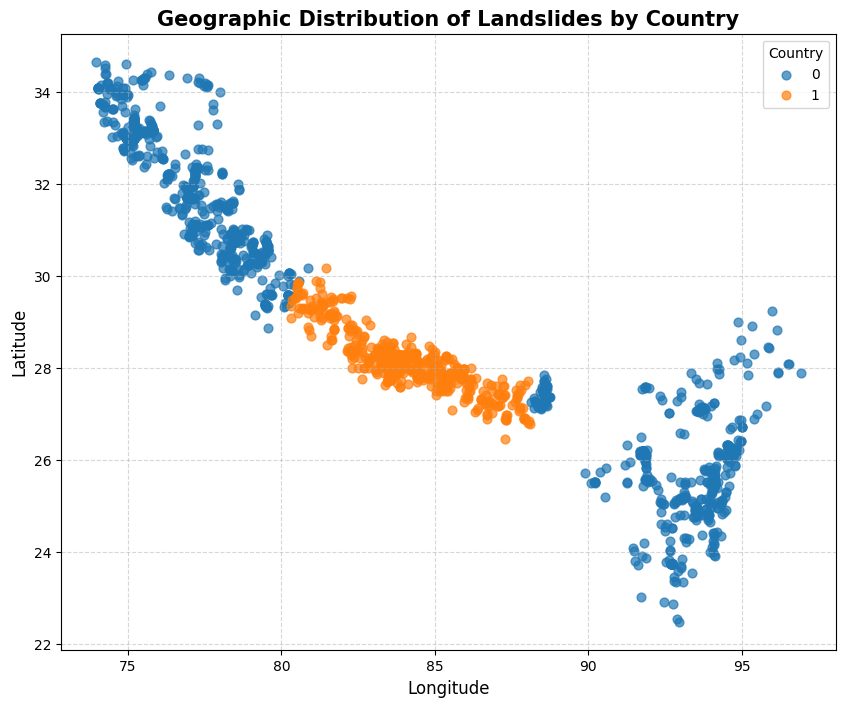

In [105]:
plt.figure(figsize=(10,8))

# Plot for each country separately
for country in himalaya_df['country_name'].unique():

    country_data = himalaya_df[
        himalaya_df['country_name'] == country
    ]

    plt.scatter(
        country_data['longitude'],
        country_data['latitude'],
        label=country,
        alpha=0.7,
        s=40
    )

# Labels and title
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

plt.title(
    'Geographic Distribution of Landslides by Country',
    fontsize=15,
    fontweight='bold'
)

# Legend
plt.legend(title='Country')

# Grid
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Graph Analysis :
- We have only focused on landslides in the himalayan regions of India and Nepal.
- Nepal also has a high concentration of landslides.

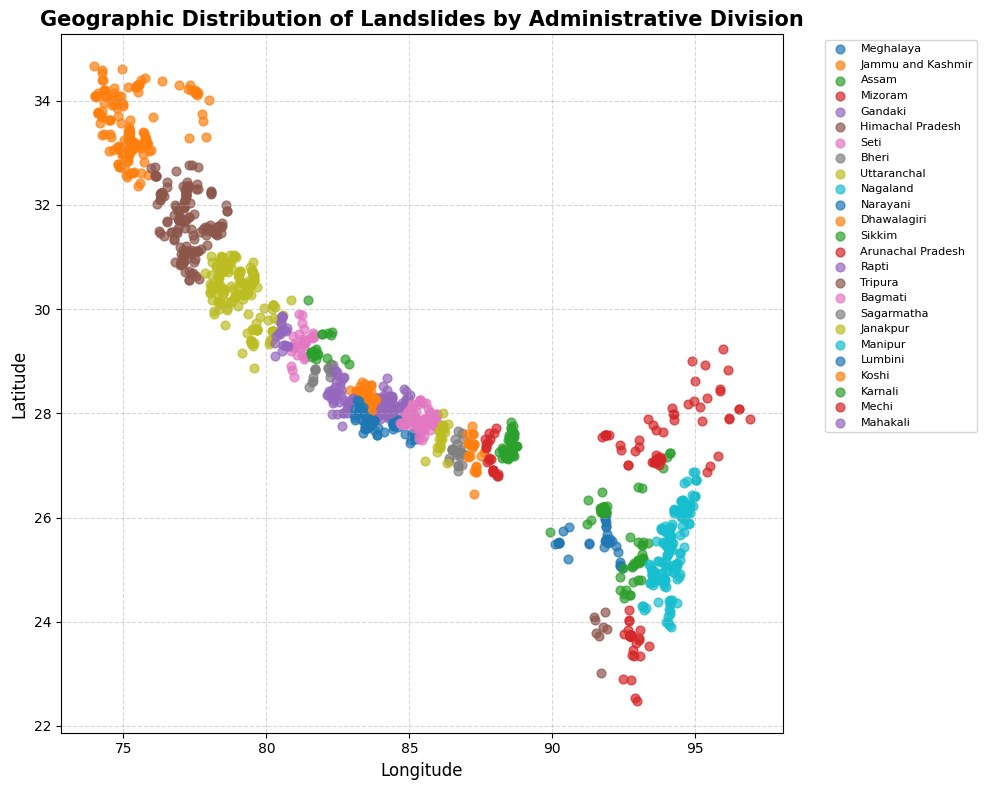

In [106]:
plt.figure(figsize=(10,8))

states = himalaya_df['admin_division_name'].unique()

for state in states:

    state_data = himalaya_df[
        himalaya_df['admin_division_name'] == state
    ]

    plt.scatter(
        state_data['longitude'],
        state_data['latitude'],
        label=state,
        alpha=0.7,
        s=40
    )

plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

plt.title(
    'Geographic Distribution of Landslides by Administrative Division',
    fontsize=15,
    fontweight='bold'
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=8
)

plt.grid(linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

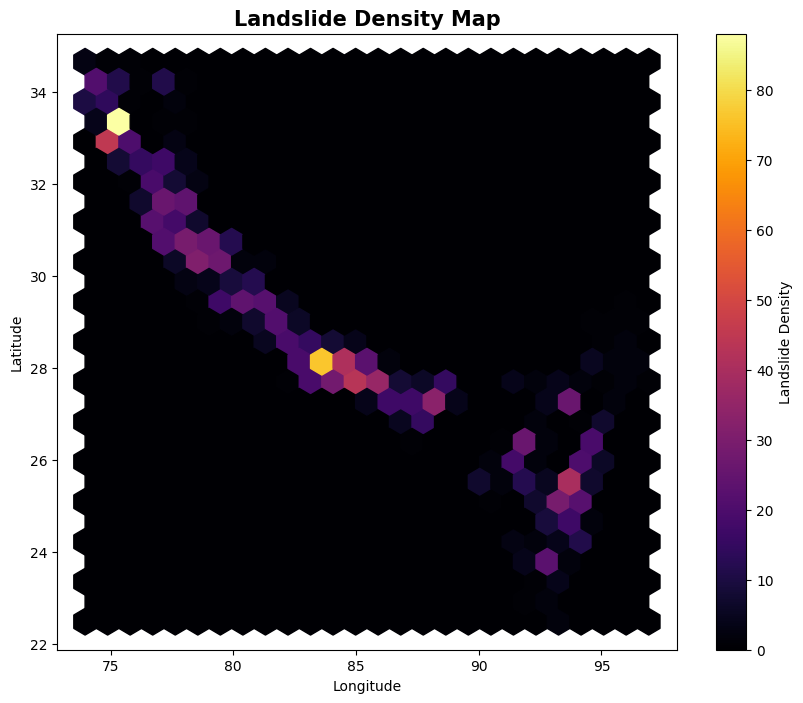

In [107]:
plt.figure(figsize=(10,8))

plt.hexbin(
    himalaya_df['longitude'],
    himalaya_df['latitude'],
    gridsize=25,
    cmap='inferno'
)

plt.colorbar(label='Landslide Density')

plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.title(
    'Landslide Density Map',
    fontsize=15,
    fontweight='bold'
)

plt.show()

Graph Analysis : 
- Jammu Kashmir and regions of Nepal have the highest landslide density.
- Most other Himalayan regions in have lower landslide density.

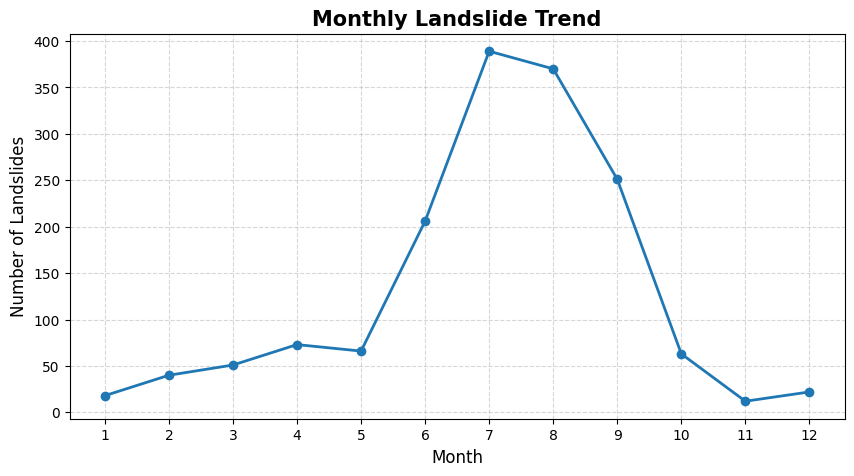

In [108]:
monthly_counts = himalaya_df['month'].value_counts().sort_index()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_counts.index,
    monthly_counts.values,
    marker='o',
    linewidth=2
)

plt.xticks(range(1,13))

plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Landslides', fontsize=12)

plt.title(
    'Monthly Landslide Trend',
    fontsize=15,
    fontweight='bold'
)

plt.grid(linestyle='--', alpha=0.5)

plt.show()

Graph Analysis : 
- From the graph, we understand there is a gradual and sharp increase in landslides during the 6th, 7th and 8th month, peak monsoon months.
- As monsoon receeds and winter starts landslides slowly decrease over time from October.

# Task 4 - Model Building and Evaluation

## Logistic Regression

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [110]:
X = himalaya_df.drop(columns=[
    "severity",
    "fatality_count",
    "event_date",
    "event_title",
    "event_description",
    "location_description",
    "source_name",
    "event_import_source",
    "gazetteer_closest_point"
])
y = himalaya_df['severity']

In [111]:
# separating numerical columns and categorical columns
numerical_cols = X.select_dtypes(
    include=['int64','float64']
).columns
numerical_cols

Index(['location_accuracy_km', 'landslide_size', 'latitude', 'longitude',
       'country_name', 'gazetteer_distance'],
      dtype='object')

In [112]:
categorical_cols = X.select_dtypes(
    include=['object','category']
).columns
categorical_cols

Index(['landslide_category', 'landslide_trigger', 'landslide_setting',
       'admin_division_name', 'season'],
      dtype='object')

In [113]:
# creating numeric pipeline
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [114]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))    # handle_unknown can handle unknown values in test data wo breaking
])

In [115]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [116]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Logistic Regression with all its trials and errors

In [133]:
# BASELINE LOGISTIC REGRESSION

model1 = Pipeline(steps=[

    ('preprocessor', preprocessor),but 

    ('classifier', LogisticRegression(
        max_iter=1000
    ))

])

# TRAIN MODEL
model1.fit(X_train, y_train)

y_pred = model1.predict(X_test)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.60      0.30      0.40        10
         low       0.76      0.90      0.82       218
      medium       0.56      0.33      0.41        85

    accuracy                           0.73       313
   macro avg       0.64      0.51      0.55       313
weighted avg       0.70      0.73      0.70       313

[[  3   5   2]
 [  2 196  20]
 [  0  57  28]]


Observations : 
- Due to imbalanced data, model shows bias towards 'low'
- 'high' and 'medium' are usually classified as 'low' due to less available data
- Accuracy of the model is fine, but predictions are imbalances
- Precision, recall and f1-score must also be evaluated as 'high' severity should have the highest priority in disaster management projects

In [134]:
# LOGISTIC REGRESSION WITH CLASS BALANCING

model2 = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))

])

# TRAIN MODEL
model2.fit(X_train, y_train)

y_pred = model2.predict(X_test)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.18      0.70      0.29        10
         low       0.87      0.65      0.74       218
      medium       0.51      0.67      0.58        85

    accuracy                           0.65       313
   macro avg       0.52      0.67      0.54       313
weighted avg       0.75      0.65      0.68       313

[[  7   1   2]
 [ 25 141  52]
 [  7  21  57]]


Observations : 
- True positives increased for 'high' and 'medium'
- However, precision for 'high' went down as now 'high' is getting more priority
- The recall value for high is good, but in real life this could mean a waste of resources due to the low precision rates

In [135]:
# MANUAL CLASS WEIGHTS

model3 = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', LogisticRegression(

        class_weight={
            'low': 1,
            'medium': 2,
            'high': 2
        },

        max_iter=1000
    ))

])

# TRAIN MODEL
model3.fit(X_train, y_train)

y_pred = model3.predict(X_test)

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

        high       0.30      0.30      0.30        10
         low       0.82      0.75      0.79       218
      medium       0.50      0.61      0.55        85

    accuracy                           0.70       313
   macro avg       0.54      0.55      0.55       313
weighted avg       0.72      0.70      0.71       313

[[  3   3   4]
 [  6 164  48]
 [  1  32  52]]


Observation : 
- Precision increased significantly for 'high'
- Recall dropped significantly for 'high' as well
- Many dangerous events were missed, around 7 out of 10, which is not a good metric to base our model off.


FINAL CONCLUSION:

1. Logistic Regression performed reasonably as a baseline model.

2. The dataset is highly imbalanced, causing bias toward
majority classes.

3. Different balancing techniques created tradeoffs between:
   - precision
   - recall
   - false positives
   - false negatives

4. Improving minority-class recall often reduced precision.

5. Logistic Regression struggled to clearly separate
medium and high severity classes.

6. This suggests:
   - class overlap
   - nonlinear relationships
   - limitations of linear classifiers

7. More advanced ensemble models such as:
   - Random Forest
   - XGBoost

may perform better on this disaster prediction dataset.


## Random Forest Algorithm

In [120]:
from sklearn.ensemble import RandomForestClassifier

In [121]:
X = himalaya_df.drop(columns=[
    "severity",
    "fatality_count",
    "event_date",
    "event_title",
    "event_description",
    "location_description",
    "source_name",
    "event_import_source",
    "gazetteer_closest_point"
])
y = himalaya_df['severity']

In [122]:
print(X.columns)

Index(['location_accuracy_km', 'landslide_category', 'landslide_trigger',
       'landslide_size', 'landslide_setting', 'latitude', 'longitude',
       'country_name', 'admin_division_name', 'gazetteer_distance', 'year',
       'month', 'season'],
      dtype='object')


In [123]:
numerical_cols = X.select_dtypes(include=['int64', 'int32', 'float64']).columns

categorical_cols = X.select_dtypes(include=['object', 'category']).columns
print(numerical_cols)
print(categorical_cols)

Index(['location_accuracy_km', 'landslide_size', 'latitude', 'longitude',
       'country_name', 'gazetteer_distance', 'year', 'month'],
      dtype='object')
Index(['landslide_category', 'landslide_trigger', 'landslide_setting',
       'admin_division_name', 'season'],
      dtype='object')


In [124]:
preprocessor = ColumnTransformer(

    transformers=[

        ('num', numerical_transformer, numerical_cols),

        ('cat', categorical_transformer, categorical_cols)

    ]

)

In [125]:
rf_model = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('classifier', RandomForestClassifier(
        max_depth=7,
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))

])

In [126]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [127]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [128]:
y_pred = rf_model.predict(X_test)

In [129]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        high       0.29      0.40      0.33        10
         low       0.85      0.75      0.80       218
      medium       0.52      0.66      0.58        85

    accuracy                           0.71       313
   macro avg       0.55      0.60      0.57       313
weighted avg       0.74      0.71      0.72       313



In [130]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("CONFUSION MATRIX")
print(cm)

CONFUSION MATRIX
[[  4   3   3]
 [  6 163  49]
 [  4  25  56]]


Observations and Conclusion : 
- Logistic Regression performed better for high-severity landslides because it learns clearer linear decision boundaries, so it can more confidently identify extreme-risk cases when patterns are strong and distinct. The drawback to it being it has low precision rate, giving many false positives but an 80% recall rate which is a very good value.
- Random Forest performed better for medium-severity landslides because it captures more complex and non-linear relationships between factors like rainfall, slope, trigger type, fatalities, and location conditions, but it only predicts high severity half of the time meaning it is not very helpful in real-life situations.
- This shows that landslide severity prediction is not purely linear — different severity classes behave differently, and ensemble models like Random Forest are often better at handling the messy middle categories where patterns overlap.

## Saving models and csv files for streamlit dashboard

In [131]:
import joblib

In [132]:
joblib.dump(
    rf_model,
    "random_forest_model.pkl"
)

['random_forest_model.pkl']

In [136]:
joblib.dump(
    model2,
    'logistic_regression_model.pkl'
)

['logistic_regression_model.pkl']

In [138]:
joblib.dump(
    numerical_transformer,
    'scaler_pipeline.pkl'
)

['scaler_pipeline.pkl']

In [139]:
joblib.dump(
    X.columns.tolist(),
    "feature_columns.pkl"
)

['feature_columns.pkl']

In [140]:
himalaya_df.columns

Index(['source_name', 'event_date', 'event_title', 'event_description',
       'location_description', 'location_accuracy_km', 'landslide_category',
       'landslide_trigger', 'landslide_size', 'landslide_setting',
       'fatality_count', 'event_import_source', 'latitude', 'longitude',
       'country_name', 'admin_division_name', 'gazetteer_closest_point',
       'gazetteer_distance', 'year', 'month', 'season', 'severity'],
      dtype='object')

## Steps to run the streamlit dashboard
- In Anaconda Prompt, navigate to the directory where app.py is stored using cd
- When we are inside the directory run "streamlit run app.py"
- A chrome or browser extension with the dashboard will load.